In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [14]:
# --------------------------
# 1) Parameters
# --------------------------
N = 2000                # oscillator Hilbert truncation (raise if |beta|^2 is large)
chi = 3              # 10^-6 * chi
drive_amp = 50          # drive amplitude 
drive_time = 0.1      # drive ramp time (microseconds)
T = 1.10               # total gate time (microseconds)
Th = T/2               # half time (echo at t=Th)

# time grid
dt = 0.001
tlist = np.arange(0, Th + dt, dt) # time points for simulation

# --------------------------
# 2) Waveform helpers
# --------------------------
def drive_function(t, args):
    """
    square pulse wait alternate 
    """
    if t < 0:
        return 0.0
    if t < drive_time:
        return drive_amp * args["sign"]
    if t < Th - drive_time:
        return 0.0
    if t < Th:
        return -1*drive_amp * args["sign"]
    return 0.0

# --------------------------
# 3) Operators
# --------------------------
a = qt.destroy(N)
n = a.dag() * a
Iosc = qt.qeye(N)

Iq = qt.qeye(2)
sz = qt.sigmaz()
sx = qt.sigmax()
sy = qt.sigmay()

# Composite operators (oscillator ⊗ qubit)
H_disp = qt.tensor(n, sz)       
a_full = qt.tensor(a, Iq)
sx_full = qt.tensor(Iosc, sx)
sy_full = qt.tensor(Iosc, sy)


# --------------------------
# 4) Build time-dependent Hamiltonians
# --------------------------

def c_ad(t, args): # coefficient for a† term
    return 1j*drive_function(t, args)

def c_a(t, args):  # coefficient for a term
    return -1j*np.conj(drive_function(t, args))

# --------------------------
# 5) Simulate for qubit |0> and |1> (σz eigenstates)
# --------------------------
vac = qt.basis(N, 0)
q0  = qt.basis(2, 0)   # σz eigenvalue +1 in QuTiP convention
q1  = qt.basis(2, 1)   # σz eigenvalue -1

def run():
    psi_q0 = qt.tensor(vac, q0)
    psi_q1 = qt.tensor(vac, q1)

    H = -chi/2 * H_disp + a_full.dag()*qt.coefficient(c_ad,args={"sign": 1}) + a_full*qt.coefficient(c_a,args={"sign": 1})
    res0_round1 = qt.mesolve(H, psi_q0, tlist, c_ops=[], e_ops=[a_full], options={"store_states": True})
    res1_round1 = qt.mesolve(H, psi_q1, tlist, c_ops=[], e_ops=[a_full], options={"store_states": True})

    psi0_round2 = sx_full * res0_round1.states[-1]  # midpoint state for qubit |0> now flipped
    psi1_round2 = sx_full * res1_round1.states[-1]  # midpoint state for qubit |1> now flipped

    H = -chi/2 * H_disp + a_full.dag()*qt.coefficient(c_ad,args={"sign": -1}) + a_full*qt.coefficient(c_a,args={"sign": -1})
    res0_round2 = qt.mesolve(H, psi0_round2, tlist, c_ops=[], e_ops=[a_full], options ={"store_states": True})
    res1_round2 = qt.mesolve(H, psi1_round2, tlist, c_ops=[], e_ops=[a_full], options ={"store_states": True})

    a_traj_q0 = np.concatenate([np.array(res0_round1.expect[0]),
                                np.array(res0_round2.expect[0])[1:]])
    a_traj_q1 = np.concatenate([np.array(res1_round1.expect[0]),
                                np.array(res1_round2.expect[0])[1:]])

    states_q0 = res0_round1.states + res0_round2.states[1:]
    states_q1 = res1_round1.states + res1_round2.states[1:]

    times = np.concatenate([tlist, tlist[1:] + Th])

    # final displacement estimates in each branch
    beta0 = a_traj_q0[-1]
    beta1 = a_traj_q1[-1]
    return a_traj_q0, a_traj_q1, beta0, beta1 , states_q0, states_q1, times

a0_echo, a1_echo, beta0_echo, beta1_echo, states0_echo, states1_echo, times_echo = run()

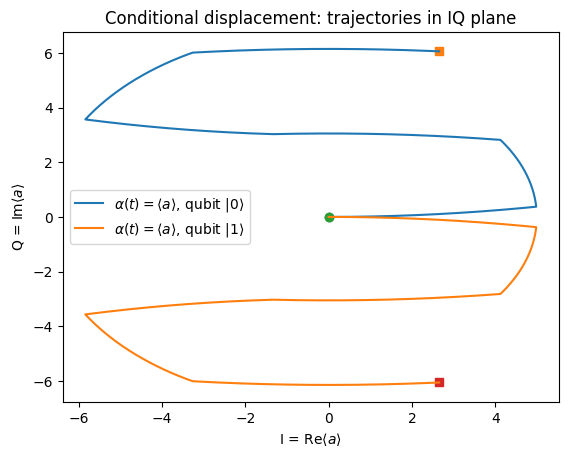

Final <a> with echo:
  qubit |0>: (2.652418985041351+6.0616345566552505j)
  qubit |1>: (2.652418985041351-6.0616345566552505j)
  Δ = 12.123269113310501j


In [13]:
# IQ-plane trajectories of alpha(t) = <a>(t) for each qubit branch

plt.figure()

# plot Q vs I (Im vs Re) for each branch
plt.plot(a0_echo.real, a0_echo.imag, label=r"$\alpha(t)=\langle a\rangle$, qubit $|0\rangle$")
plt.plot(a1_echo.real, a1_echo.imag, label=r"$\alpha(t)=\langle a\rangle$, qubit $|1\rangle$")

# mark start and end points
plt.scatter([a0_echo.real[0]], [a0_echo.imag[0]], marker="o")
plt.scatter([a0_echo.real[-1]], [a0_echo.imag[-1]], marker="s")

plt.scatter([a1_echo.real[0]], [a1_echo.imag[0]], marker="o")
plt.scatter([a1_echo.real[-1]], [a1_echo.imag[-1]], marker="s")

plt.xlabel(r"I = Re$\langle a\rangle$")
plt.ylabel(r"Q = Im$\langle a\rangle$")
plt.title("Conditional displacement: trajectories in IQ plane")
plt.legend()
plt.show()

# optional: still print final values
print("Final <a> with echo:")
print("  qubit |0>:", beta0_echo)
print("  qubit |1>:", beta1_echo)
print("  Δ =", beta0_echo - beta1_echo)

In [15]:
rho_cav0 = states0_echo[-1].ptrace(0)     # if states0_echo[-1] is a ket, ptrace returns a density matrix
print((rho_cav0*a).tr())

(2.652367119571656+6.061645756252669j)


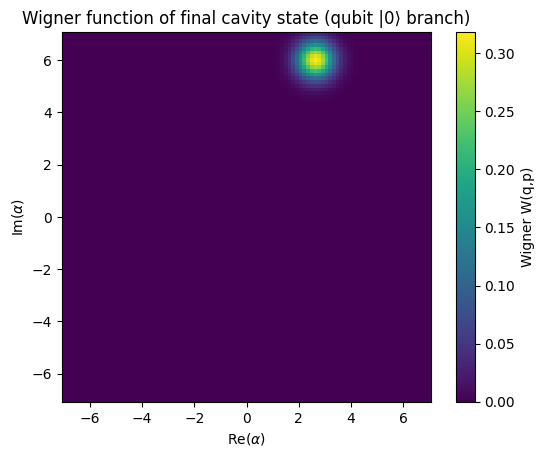

(2.652367119571656+6.061645756252669j)


In [16]:
# --- phase-space grid ---
xvec = np.linspace(-10, 10, 100)  # q
yvec = np.linspace(-10, 10, 100)  # p

# --- Wigner ---
W = qt.wigner(rho_cav0, xvec, yvec)   # shape (len(yvec), len(xvec)) in QuTiP

# --- plot ---
plt.imshow(
    W,
    extent=[xvec.min()/np.sqrt(2), xvec.max()/np.sqrt(2),
            yvec.min()/np.sqrt(2), yvec.max()/np.sqrt(2)],
    origin="lower",
    aspect="equal",
)
plt.xlabel(r"Re($\alpha$)")
plt.ylabel(r"Im($\alpha$)")

plt.title("Wigner function of final cavity state (qubit |0⟩ branch)")
plt.colorbar(label="Wigner W(q,p)")
plt.show()

print((rho_cav0*a).tr())

In [ ]:
import math
from scipy.integrate import quad

# ---- parameters (same as your Mathematica) ----
c = 3.0
T = 1.1
l = 0.1
m =50.0

# ---- UnitStep + s(t) ----
# Mathematica UnitStep[x] is 1 for x >= 0, else 0
def unit_step(x: float) -> float:
    return 1.0 if x >= 0.0 else 0.0

# s(t) = m (UnitStep[t] - UnitStep[t-l])  => m on [0,l), 0 otherwise
def s(t: float) -> float:
    return m * (unit_step(t) - unit_step(t - l))

# q(t) = s(t) - s(t-(T/2-l)) - s(t-T/2) + s(t-(T-l))
def q(t: float) -> float:
    return (
        s(t)
        - s(t - (T / 2.0 - l))
        - s(t - T / 2.0)
        + s(t - (T - l))
    )

# ---------------------------------------------------------------------
# Your Mathematica computes:
#   yDouble1 = -(c^2/4) ∫_{p=0}^{T/2} ∫_{t=0}^{p} a(t) dt dp
#   yDouble2 = -(c^2/4) ∫_{p=T/2}^{T} ∫_{t=0}^{p} a(t)*Sign(t-T/2) dt dp
# where a(p)=∫_0^p q(t) dt.
#
# For MUCH better convergence, collapse the nested integrals to:
#   y = -(c^2/8) [ ∫_0^{T/2} q(u) u^2 du  +  ∫_{T/2}^{T} q(u) (T-u)^2 du ]
# (This is exactly equivalent to yDouble1 + yDouble2.)
# ---------------------------------------------------------------------

# discontinuity locations of q(t) to help quad converge
breaks = sorted(set([0.0, l, T/2.0 - l, T/2.0, T/2.0 + l, T - l, T]))

def quad_with_breaks(f, a, b):
    pts = [x for x in breaks if a < x < b]  # only interior breakpoints
    val, err = quad(f, a, b, points=pts, limit=200)
    return val

I1 = quad_with_breaks(lambda u: q(u) * (u**2), 0.0, T/2.0)
I2 = quad_with_breaks(lambda u: q(u) * ((T - u)**2), T/2.0, T)

y = -(c**2) / 8.0 * (I1 + I2)

print("yDouble1 + yDouble2 =", y)


yDouble1 + yDouble2 = 2.784375


In [ ]:
(5*(Th-0.2)+0.1*5)*2*c/2

6.75